In [1]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

In [2]:
from tensorflow.keras.applications import MobileNetV2

In [3]:
from tensorflow.keras.layers import AveragePooling2D

In [4]:
from tensorflow.keras.layers import Dropout

In [47]:
from tensorflow.keras.layers import Flatten

In [5]:
from tensorflow.keras.layers import Dense

In [6]:
from tensorflow.keras.layers import Input

In [7]:
from tensorflow.keras.models import Model

In [57]:
from tensorflow.keras.optimizers import Adam

In [9]:
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input

In [10]:
from tensorflow.keras.preprocessing.image import img_to_array

In [11]:
from tensorflow.keras.preprocessing.image import load_img

In [12]:
from tensorflow.keras.utils import to_categorical

In [13]:
from sklearn.preprocessing import LabelBinarizer

In [14]:
from sklearn.model_selection import train_test_split

In [15]:
from sklearn.metrics import classification_report

In [16]:
import cv2
print(cv2.__version__)

4.12.0


In [17]:
from imutils import paths

In [18]:
import matplotlib.pyplot as plt
import numpy as np
import argparse
import os

In [27]:

import argparse

ap = argparse.ArgumentParser()
ap.add_argument("-d", "--dataset", required=True,
    help="path to input dataset")
ap.add_argument("-p", "--plot", type=str, default="plot.png",
    help="path to output loss/accuracy plot")
ap.add_argument("-m", "--model", type=str, default="mask_detectorch.model",
    help="path to output face mask detector model")

try:
    args = vars(ap.parse_args())
except SystemExit:
    # Notebook fallback
    args = {
        "dataset": "dataset",
        "plot": "plot.png",
        "model": "mask_detectorch.model"
    }

print("[INFO] Arguments loaded successfully:")
print(args)


[INFO] Arguments loaded successfully:
{'dataset': 'dataset', 'plot': 'plot.png', 'model': 'mask_detectorch.model'}


usage: ipykernel_launcher.py [-h] -d DATASET [-p PLOT] [-m MODEL]
ipykernel_launcher.py: error: the following arguments are required: -d/--dataset


In [28]:
INIT_LR = 1e-4
EPOCHS = 20
BS = 32

In [29]:
print("[INFO] loading images...")
imagePaths=list(paths.list_images(args["dataset"]))

[INFO] loading images...


In [30]:
data=[]
labels=[]


In [39]:
import numpy as np
import os
from tensorflow.keras.preprocessing.image import load_img, img_to_array
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input

data = []
labels = []
bad = []   # to record bad images

for imagePath in imagePaths:
    label = imagePath.split(os.path.sep)[-2]
    try:
        # Force RGB mode so all images have shape (224, 224, 3)
        image = load_img(imagePath, target_size=(224, 224), color_mode='rgb')
        image = img_to_array(image)
        image = preprocess_input(image)
        data.append(image)
        labels.append(label)
    except Exception as e:
        bad.append(imagePath)
        print(f"[WARN] Skipping {imagePath}: {e}")

# ✅ Convert safely
data = np.stack(data, axis=0).astype("float32")
labels = np.array(labels)

print("[INFO] Data and labels loaded successfully:")
print("Data shape:", data.shape)
print("Labels shape:", labels.shape)
print("Skipped images:", len(bad))
    

[INFO] Data and labels loaded successfully:
Data shape: (3846, 224, 224, 3)
Labels shape: (3846,)
Skipped images: 0


In [55]:
labels

array(['without_mask', 'without_mask', 'without_mask', ..., 'with_mask',
       'with_mask', 'with_mask'], dtype='<U12')

In [40]:
lb=LabelBinarizer()
labels=lb.fit_transform(labels)
labels=to_categorical(labels)

In [41]:
(trainX, testX, trainY, testY) = train_test_split(data, labels,
	test_size=0.20, stratify=labels, random_state=42)

In [42]:
aug=ImageDataGenerator(
    rotation_range=20,
    zoom_range=0.15,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.15,
    horizontal_flip=True,
    fill_mode="nearest")

In [44]:
data.shape

(3846, 224, 224, 3)

In [45]:
basemodel=MobileNetV2(weights='imagenet',include_top=False,input_tensor=Input(shape=(224,224,3)))

C:\Users\User\AppData\Local\Temp\ipykernel_4176\4176867536.py:1: UserWarning: `input_shape` is undefined or non-square, or `rows` is not in [96, 128, 160, 192, 224]. Weights for input shape (224, 224) will be loaded as the default.
  basemodel=MobileNetV2(weights='imagenet',include_top=False,input_tensor=Input(shape=(224,224,3)))


9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 3s 0us/step


In [51]:
headmodel=basemodel.output
headmodel=AveragePooling2D(pool_size=(7,7))(headmodel)
headmodel=Flatten(name="flatten")(headmodel)
headmodel=Dense(128,activation="relu")(headmodel)
headmodel=Dropout(0.5)(headmodel)
headmodel=Dense(2,activation="softmax")(headmodel)


In [53]:
model = Model(inputs=basemodel.input, outputs=headmodel)

In [55]:
for layer in basemodel.layers:
	layer.trainable = False

In [ ]:
INIT_LR = 1e-4
EPOCHS = 20
BS = 32

In [59]:
print("[INFO] compiling model...")
opt = Adam(learning_rate=INIT_LR)
model.compile(loss="binary_crossentropy", optimizer=opt,
	metrics=["accuracy"])


[INFO] compiling model...


In [60]:
print("[INFO] training head...")
H = model.fit(
	aug.flow(trainX, trainY, batch_size=BS),
	steps_per_epoch=len(trainX) // BS,
	validation_data=(testX, testY),
	validation_steps=len(testX) // BS,
	epochs=EPOCHS)

[INFO] training head...


C:\Anaconda3\envs\aimj\Lib\site-packages\keras\src\trainers\data_adapters\py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/20
96/96 ━━━━━━━━━━━━━━━━━━━━ 450s 5s/step - accuracy: 0.8706 - loss: 0.3933 - val_accuracy: 0.9779 - val_loss: 0.1462
Epoch 2/20
 1/96 ━━━━━━━━━━━━━━━━━━━━ 2:21 1s/step - accuracy: 1.0000 - loss: 0.1728

C:\Anaconda3\envs\aimj\Lib\site-packages\keras\src\trainers\epoch_iterator.py:116: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()


96/96 ━━━━━━━━━━━━━━━━━━━━ 43s 436ms/step - accuracy: 1.0000 - loss: 0.1728 - val_accuracy: 0.9779 - val_loss: 0.1447
Epoch 3/20
96/96 ━━━━━━━━━━━━━━━━━━━━ 204s 2s/step - accuracy: 0.9616 - loss: 0.1491 - val_accuracy: 0.9831 - val_loss: 0.0815
Epoch 4/20
96/96 ━━━━━━━━━━━━━━━━━━━━ 37s 374ms/step - accuracy: 0.9688 - loss: 0.1052 - val_accuracy: 0.9831 - val_loss: 0.0811
Epoch 5/20
96/96 ━━━━━━━━━━━━━━━━━━━━ 204s 2s/step - accuracy: 0.9721 - loss: 0.0995 - val_accuracy: 0.9909 - val_loss: 0.0596
Epoch 6/20
96/96 ━━━━━━━━━━━━━━━━━━━━ 43s 434ms/step - accuracy: 0.9062 - loss: 0.1653 - val_accuracy: 0.9896 - val_loss: 0.0594
Epoch 7/20
96/96 ━━━━━━━━━━━━━━━━━━━━ 201s 2s/step - accuracy: 0.9803 - loss: 0.0776 - val_accuracy: 0.9896 - val_loss: 0.0511
Epoch 8/20
96/96 ━━━━━━━━━━━━━━━━━━━━ 43s 434ms/step - accuracy: 0.9375 - loss: 0.0948 - val_accuracy: 0.9883 - val_loss: 0.0511
Epoch 9/20
96/96 ━━━━━━━━━━━━━━━━━━━━ 204s 2s/step - accuracy: 0.9823 - loss: 0.0646 - val_accuracy: 0.9896 - val_

In [61]:
print("[INFO] evaluating network...")
predIdxs = model.predict(testX, batch_size=BS)


[INFO] evaluating network...
25/25 ━━━━━━━━━━━━━━━━━━━━ 42s 2s/step


In [62]:
predIdxs = np.argmax(predIdxs, axis=1)

In [63]:
print(classification_report(testY.argmax(axis=1), predIdxs,
	target_names=lb.classes_))

              precision    recall  f1-score   support

   with_mask       0.99      0.99      0.99       384
without_mask       0.99      0.99      0.99       386

    accuracy                           0.99       770
   macro avg       0.99      0.99      0.99       770
weighted avg       0.99      0.99      0.99       770



KeyError: 'acc'

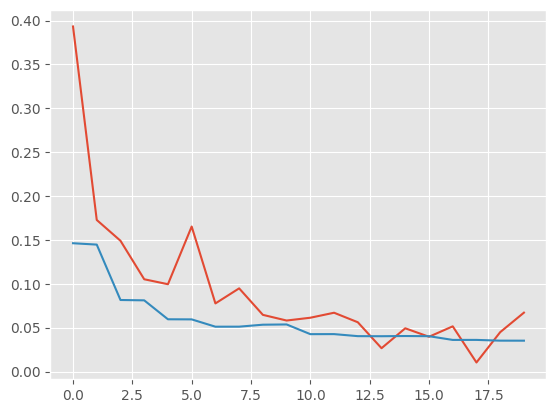

In [64]:
N = EPOCHS
plt.style.use("ggplot")
plt.figure()
plt.plot(np.arange(0, N), H.history["loss"], label="train_loss")
plt.plot(np.arange(0, N), H.history["val_loss"], label="val_loss")
plt.plot(np.arange(0, N), H.history["acc"], label="train_acc")
plt.plot(np.arange(0, N), H.history["val_acc"], label="val_acc")
plt.title("Training Loss and Accuracy")
plt.xlabel("Epoch #")
plt.ylabel("Loss/Accuracy")
plt.legend(loc="lower left")
plt.savefig(args["plot"])